In [15]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.color as skc

from utils.utils import (fast_down_sample, fast_up_sample, 
                         make_image_collection, read_image_collection,
                         read_config, 
                         class_to_artificial, artificial_to_rgb, 
                         class_to_vegetal, vegetal_to_rgb,
                         class_to_rgb,
                         fast_down_sample, fast_up_sample)

from pprint import pprint
from pathlib import Path


In [16]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
conf = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir) 


Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'image_collection': PosixPath('/workspaces/flairimages/data/test/testimagecollection.npy'),
 'image_collection_index': PosixPath('/workspaces/flairimages/data/test/testimagecollectionindex.npy'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs')}


image_data.shape:(10000, 64, 64, 8)


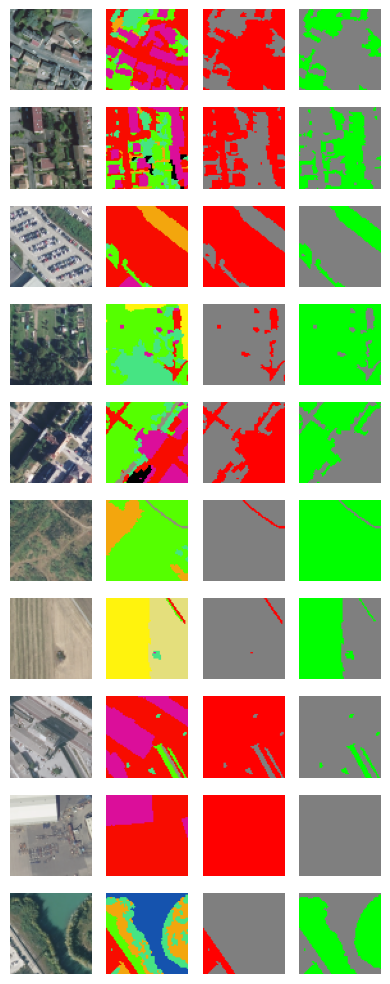

In [17]:
# test the image collection apparent consistency
image_data, image_indices = read_image_collection(conf=conf)
print(f"image_data.shape:{image_data.shape}")

plt.figure(figsize=(4,10))
for i, index in enumerate(np.random.randint(low=0, high=image_data.shape[0], size=10)):
    img= image_data[index,:,:,:3]
    msk = image_data[index,:,:,-3]
    artificial = image_data[index,:,:,-2]
    vegetal = image_data[index,:,:, -1]

    plt.subplot(10, 4, 4*i+1)
    plt.axis('off')
    plt.imshow(img)
    #
    plt.subplot(10, 4, 4*i+2)
    plt.axis('off')
    plt.imshow(class_to_rgb(arr=msk,conf=conf))
    
    plt.subplot(10, 4, 4*i+3)
    plt.axis('off')
    plt.imshow(artificial_to_rgb(arr=artificial, conf=conf))
    
    plt.subplot(10, 4, 4*i+4)
    plt.axis('off')
    plt.imshow(vegetal_to_rgb(arr=vegetal, conf=conf))
    
    plt.tight_layout()
    

float64
float64
float64
float64
float64
float64


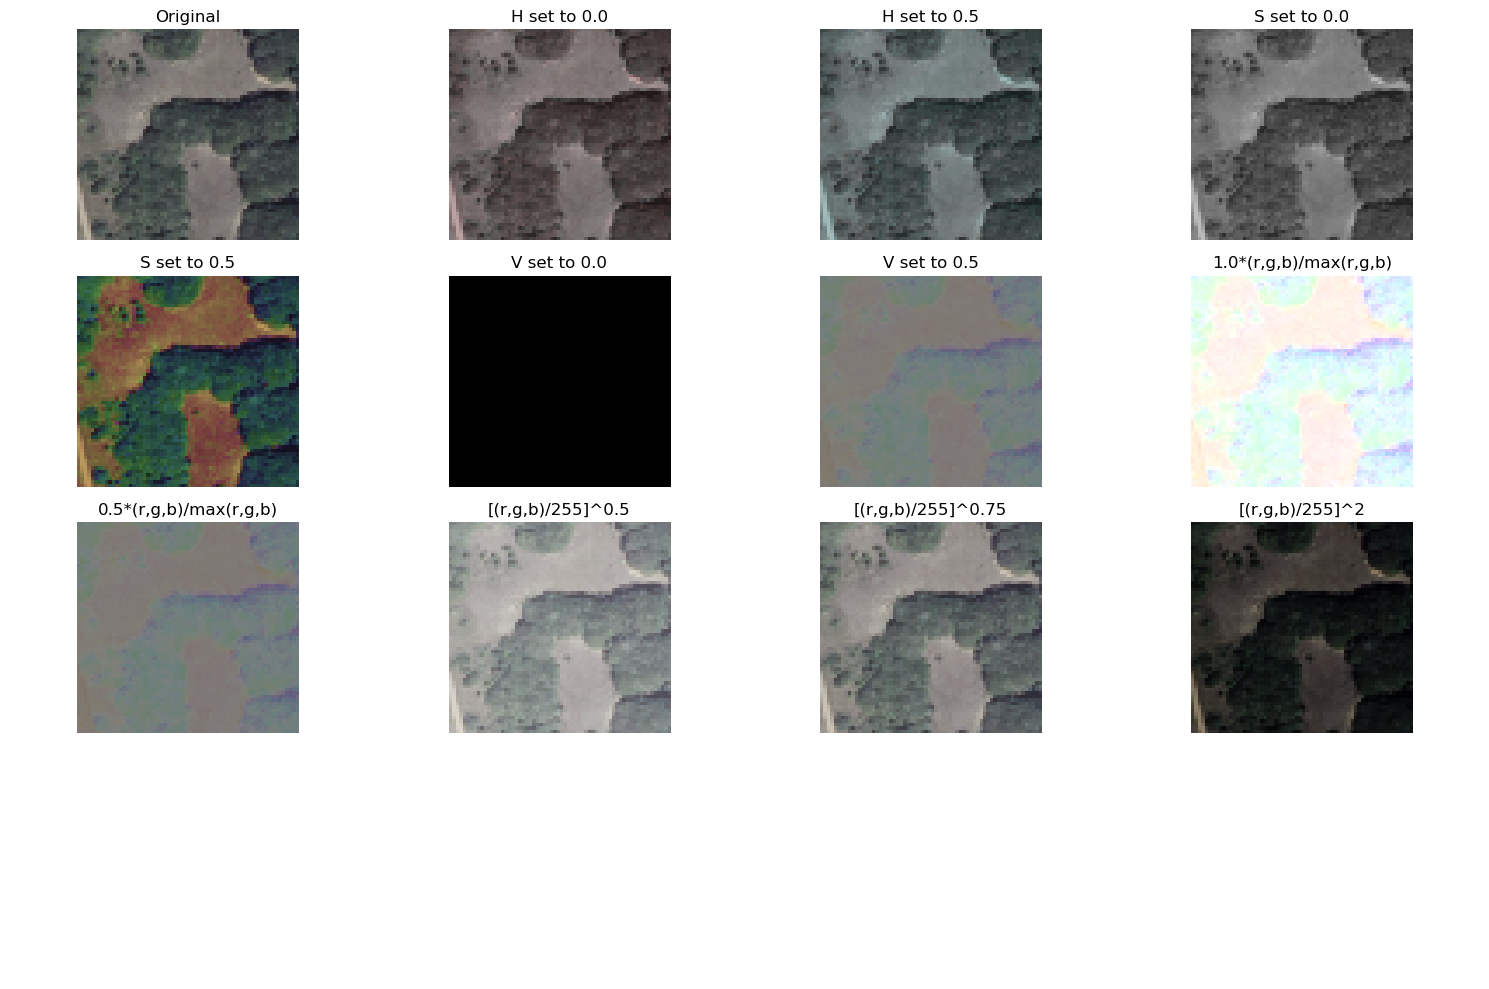

In [18]:
some_i =np.random.randint(low=0, high=image_data.shape[0])
img = image_data[some_i,:-3]
mask = image_data[some_i,:,:,-3]

# full resolution image and mask

#TODO: select a random index in image_indices, not directly from df
# select a random record from df
# and extract the name, image and mask file paths.
some_i = np.random.choice(image_indices.shape[0])
im_index = image_indices[some_i]

# down_sampled image and mask
img = image_data[some_i][:-3]
mask = image_data[some_i][:,:,-3]



# test various transformations
fig, axes = plt.subplots(4,4, figsize=(15,10) )    
for ax in axes.flatten():
    ax.axis("off")
axes = iter(axes.flatten())
#
ax=next(axes)
ax.axis("off")
ax.imshow(img[:,:,:3])
ax.set_title("Original")
#
for channel in range(3):
    for v in [0.0,0.5]:
        ax=next(axes)
        ax.axis("off")
        test=skc.rgb2hsv(img[:,:,:3])
        print(test.dtype)
        test[:,:,channel] = v 
        ax.imshow(skc.hsv2rgb(test))#, cmap='hsv')
        ax.set_title(f"{'HSV'[channel]} set to {v}")
#
for f in [1.0,0.5]:
    ax=next(axes)
    ax.axis("off")
    test = img[:,:,:3]
    test=f*test/np.max(test, axis=(-1,), keepdims=True)
    ax.imshow(test)
    ax.set_title(f"{f:0.1f}*(r,g,b)/max(r,g,b)")
#
for alpha in [0.5, 0.75, 2]:
    ax=next(axes)
    ax.axis("off")
    test=(img[:,:,:3]/255)**alpha
    ax.imshow(test)
    ax.set_title(f"[(r,g,b)/255]^{alpha}")
plt.tight_layout()

